# ML Assignment 2 — Dry Bean Multiclass Classification

## Objective
Build and compare five classification models on a public multiclass dataset and evaluate them using Accuracy, AUC, Precision, Recall, F1 and MCC.

Required models:
1. Logistic Regression
2. Decision Tree
3. KNN
4. Naive Bayes
5. Random Forest

## 1. Dataset Selection

**Dataset:** UCI Dry Bean Dataset

- 13,611 instances
- 16 numerical features
- 7 target classes
- Multiclass classification

The target column is `Class`.

## 2. Import Libraries and Load the Dataset

In [1]:
!pip install ucimlrepo

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

In [3]:
dry_bean = fetch_ucirepo(id=602)

In [4]:
X = dry_bean.data.features
y = dry_bean.data.targets
print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget column:")
print(y.columns.tolist())

Features shape: (13611, 16)
Target shape: (13611, 1)

Feature columns:
['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRatio', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'Roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4']

Target column:
['Class']


In [5]:
df = pd.concat([X, y], axis=1)
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


## 3. Looking at the data and Data Quality

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRatio      13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  Roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [7]:
print(df.isnull().sum())

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRatio        0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
Roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64


In [8]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860154,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [9]:
print(df["Class"].value_counts())
print("\nNumber of classes:", df["Class"].nunique())

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

Number of classes: 7


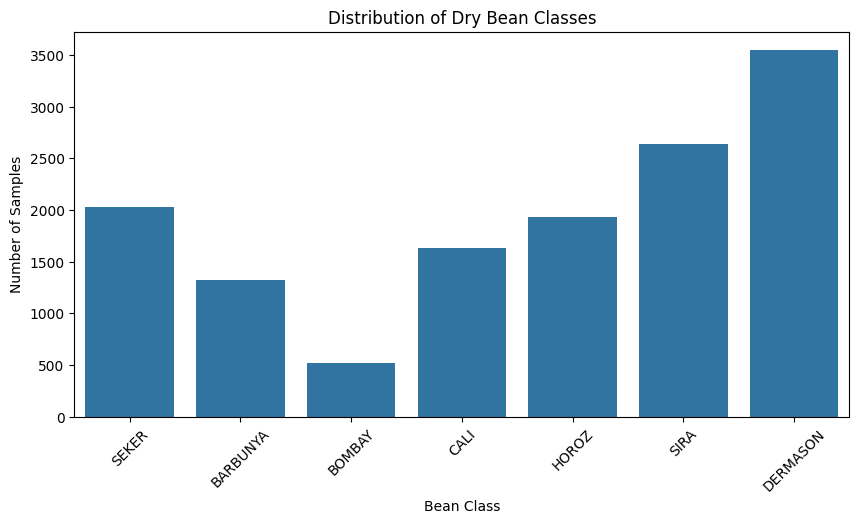

In [10]:
#Visualize class distribution
plt.figure(figsize=(10, 5))

sns.countplot(data=df, x="Class")

plt.title("Distribution of Dry Bean Classes")
plt.xlabel("Bean Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)

plt.show()

## 4. Exploratory Data Analysis (EDA)

In [11]:
# Calculate class percentages
class_percentage = df["Class"].value_counts(normalize=True) * 100

print(class_percentage.round(2))

Class
DERMASON    26.05
SIRA        19.37
SEKER       14.89
HOROZ       14.17
CALI        11.98
BARBUNYA     9.71
BOMBAY       3.84
Name: proportion, dtype: float64


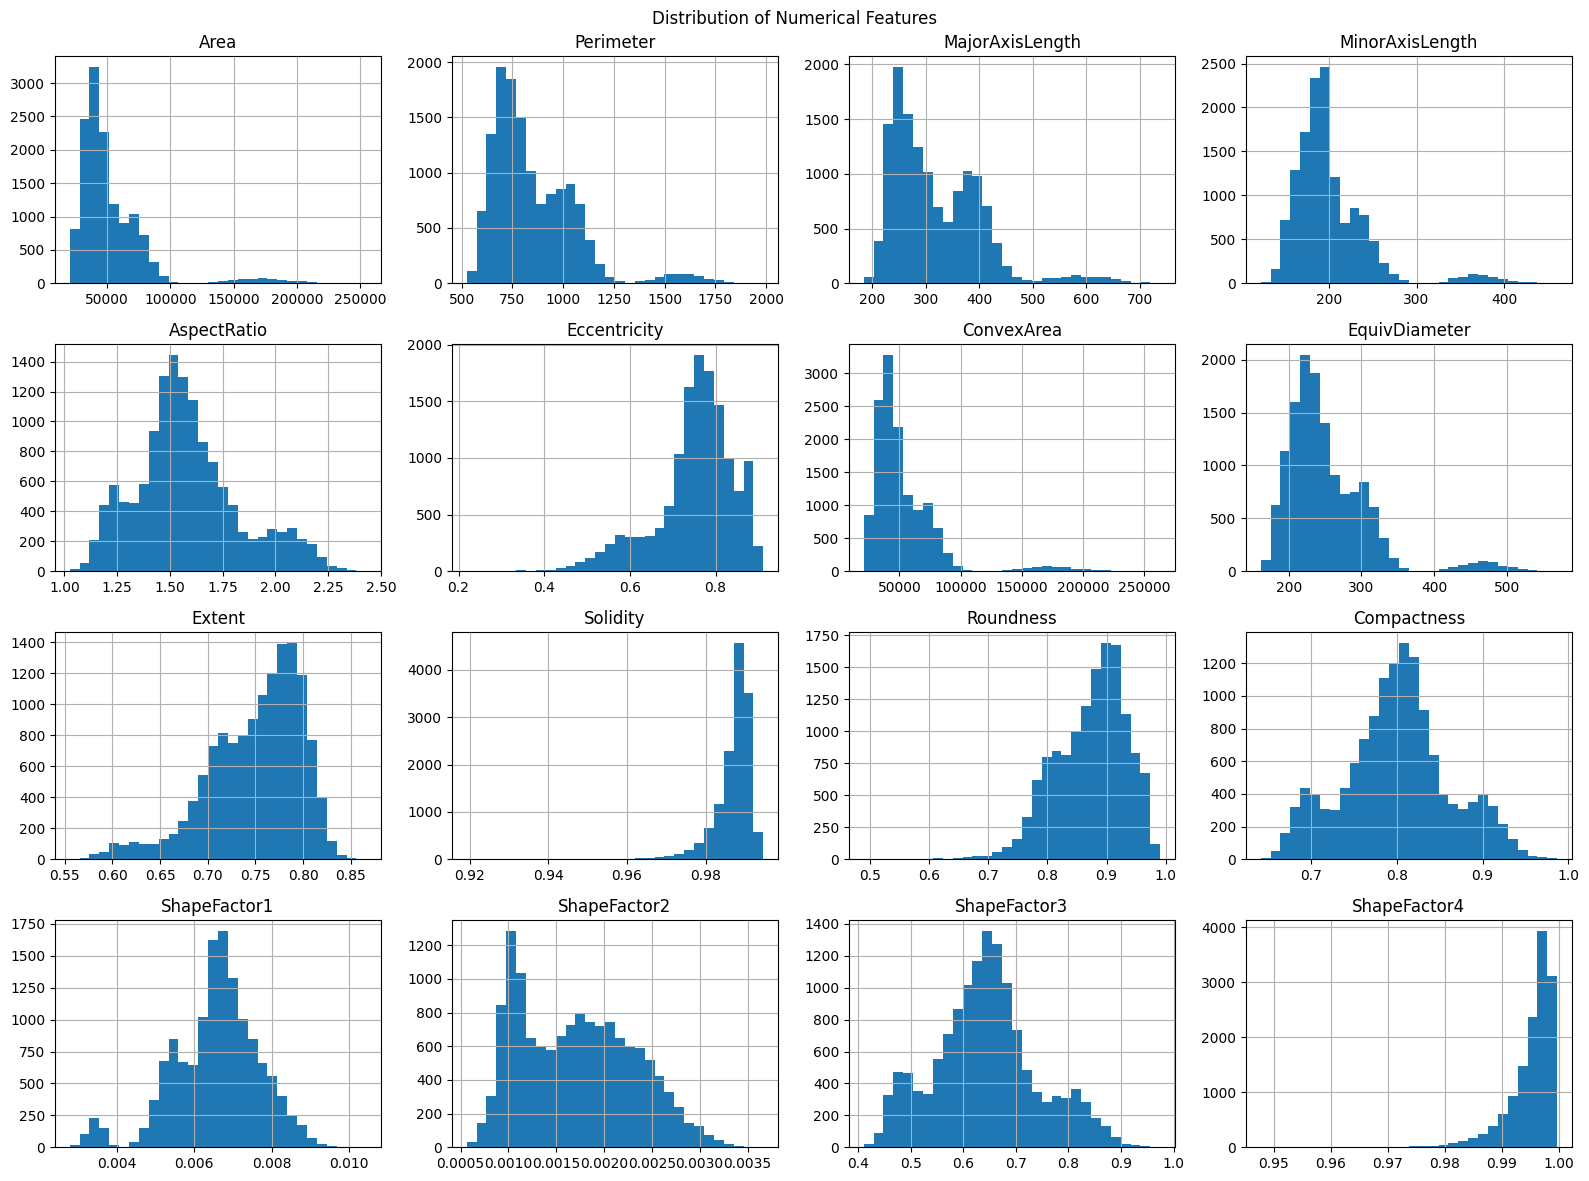

In [12]:
#Distribution of numerical features
df.hist(
    figsize=(16, 12),
    bins=30
)

plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()

plt.show()

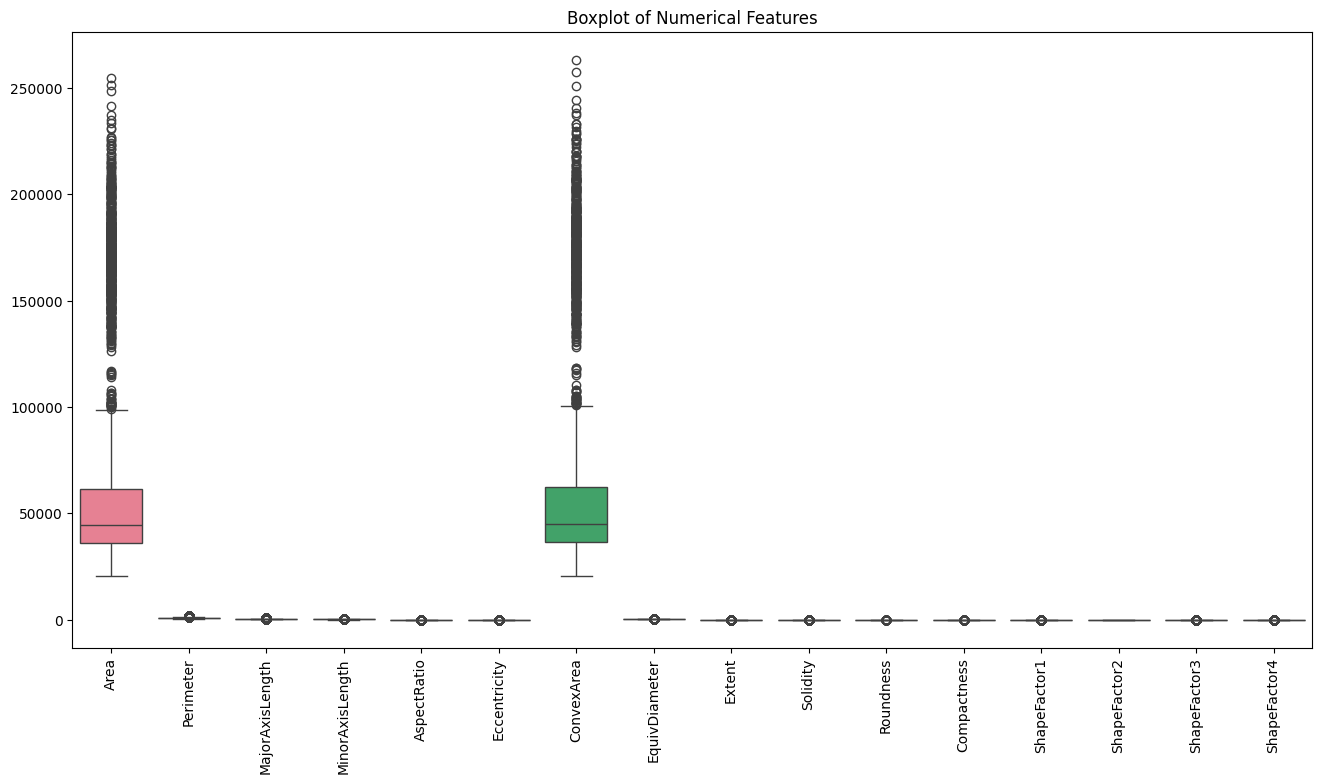

In [13]:
#Boxplots for detecting potential outliers
plt.figure(figsize=(16, 8))

sns.boxplot(data=df.drop(columns=["Class"]))

plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=90)

plt.show()

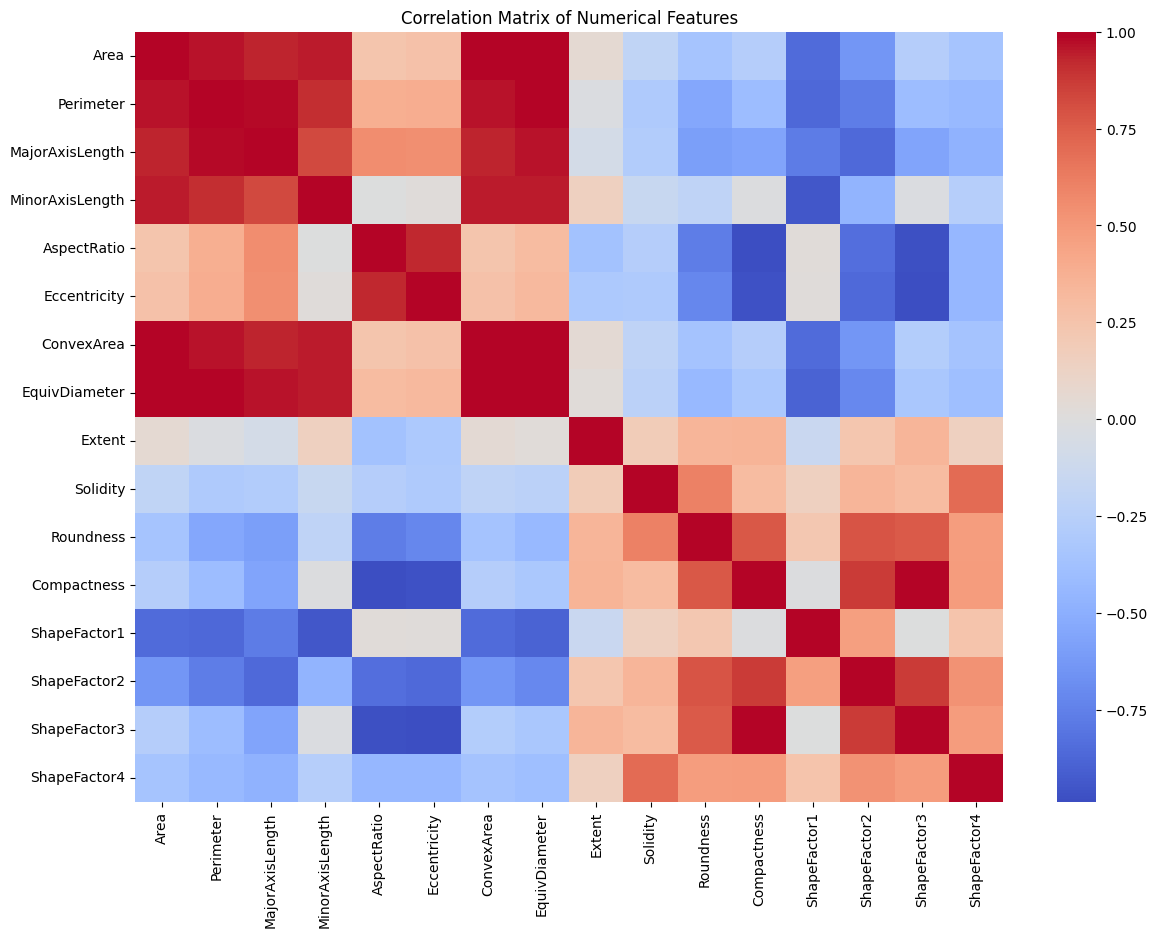

In [14]:
#Correlation matrix
plt.figure(figsize=(14, 10))

correlation = df.drop(columns=["Class"]).corr()

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

In [15]:
#Identify numerical features
numeric_features = df.select_dtypes(include=np.number).columns.tolist()

print("Number of numerical features:", len(numeric_features))
print("\nNumerical features:")
print(numeric_features)

Number of numerical features: 16

Numerical features:
['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRatio', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'Roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4']


## 5. Data Quality Checks and Feature preparation

In [16]:
#Check duplicate records
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 68


In [17]:
#Check unique values in the target
print("Unique target classes:")
print(df["Class"].unique())

print("\nNumber of unique classes:", df["Class"].nunique())

Unique target classes:
['SEKER' 'BARBUNYA' 'BOMBAY' 'CALI' 'HOROZ' 'SIRA' 'DERMASON']

Number of unique classes: 7


In [18]:
#Compare feature scales
scale_summary = df[numeric_features].agg(["min", "max", "mean", "std"]).T

print(scale_summary)

                          min            max          mean           std
Area             20420.000000  254616.000000  53048.284549  29324.095717
Perimeter          524.736000    1985.370000    855.283459    214.289696
MajorAxisLength    183.601165     738.860154    320.141867     85.694186
MinorAxisLength    122.512653     460.198497    202.270714     44.970091
AspectRatio          1.024868       2.430306      1.583242      0.246678
Eccentricity         0.218951       0.911423      0.750895      0.092002
ConvexArea       20684.000000  263261.000000  53768.200206  29774.915817
EquivDiameter      161.243764     569.374358    253.064220     59.177120
Extent               0.555315       0.866195      0.749733      0.049086
Solidity             0.919246       0.994677      0.987143      0.004660
Roundness            0.489618       0.990685      0.873282      0.059520
Compactness          0.640577       0.987303      0.799864      0.061713
ShapeFactor1         0.002778       0.010451      0

In [19]:
#Prepare X and y for ML
X = df[numeric_features]
y = df["Class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst 5 rows of X:")
display(X.head())

print("\nFirst 5 target values:")
display(y.head())

X shape: (13611, 16)
y shape: (13611,)

First 5 rows of X:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166



First 5 target values:


,Class
0,SEKER
1,SEKER
2,SEKER
3,SEKER
4,SEKER


In [20]:
#Import the preprocessing tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## 6. Data preparation and Train/Test Split

The target variable is kept as the original class labels because scikit-learn classifiers support string class labels directly.

The dataset is split using an 80/20 stratified train/test split with `random_state=42`. Feature scaling is applied inside the Logistic Regression and KNN pipelines, while Decision Tree, Random Forest and Gaussian Naive Bayes use the original numerical features.

In [21]:
#Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (10888, 16)
X_test : (2723, 16)
y_train: (10888,)
y_test : (2723,)


In [22]:
#Verify class distribution after splitting
print("Training class distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(3))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True).sort_index().round(3))

Training class distribution:
Class
BARBUNYA    0.097
BOMBAY      0.038
CALI        0.120
DERMASON    0.261
HOROZ       0.142
SEKER       0.149
SIRA        0.194
Name: proportion, dtype: float64

Testing class distribution:
Class
BARBUNYA    0.097
BOMBAY      0.038
CALI        0.120
DERMASON    0.260
HOROZ       0.142
SEKER       0.149
SIRA        0.194
Name: proportion, dtype: float64


In [23]:
# Confirm the train/test split used for model development
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Number of features:", X_train.shape[1])
print("Number of target classes:", y_train.nunique())

print("\nScaling strategy:")
print("- Logistic Regression: StandardScaler inside Pipeline")
print("- KNN: StandardScaler inside Pipeline")
print("- Decision Tree: original features")
print("- Naive Bayes: original features")
print("- Random Forest: original features")

Training samples: 10888
Testing samples: 2723
Number of features: 16
Number of target classes: 7

Scaling strategy:
- Logistic Regression: StandardScaler inside Pipeline
- KNN: StandardScaler inside Pipeline
- Decision Tree: original features
- Naive Bayes: original features
- Random Forest: original features


### Preprocessing decision

- **Target (`Class`)**: retained as categorical class names; no `LabelEncoder` is needed.
- **Train/test split**: 80/20 with stratification and `random_state=42`.
- **Standardization**: performed within the Logistic Regression and KNN pipelines to prevent data leakage.
- **Tree-based and Gaussian Naive Bayes models**: trained on the original numerical feature values.

## 7. Model Building and Training

Five required classifiers are trained on the same training split. Each model is then evaluated on the same held-out test set.

In [24]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

#Create the Logistic Regression pipeline
lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

# Train
lr_model.fit(X_train, y_train)
# Create predictions
y_pred_lr = lr_model.predict(X_test)

print("First 20 predictions:")
print(y_pred_lr[:20])

# Accuracy
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

First 20 predictions:
['DERMASON' 'BOMBAY' 'SIRA' 'SEKER' 'BARBUNYA' 'SEKER' 'DERMASON' 'SIRA'
 'CALI' 'HOROZ' 'DERMASON' 'DERMASON' 'DERMASON' 'HOROZ' 'CALI' 'DERMASON'
 'SEKER' 'DERMASON' 'BOMBAY' 'BOMBAY']
Logistic Regression Accuracy: 0.9206757253029747


In [25]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier
# Create model
dt_model = DecisionTreeClassifier(random_state=42)
#Train the model
dt_model.fit(X_train, y_train)
# Predict
y_pred_dt = dt_model.predict(X_test)
#Accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.8920308483290489


In [26]:
#KNN
from sklearn.neighbors import KNeighborsClassifier
# Create model
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])
#Train the model
knn_model.fit(X_train, y_train)
# Predict
y_pred_knn = knn_model.predict(X_test)
# Accuracy
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.9166360631656262


In [27]:
#Naive Bayes
from sklearn.naive_bayes import GaussianNB
# Create model
nb_model = GaussianNB()
#Train the model
nb_model.fit(X_train, y_train)
#Predict
y_pred_nb = nb_model.predict(X_test)
# Accuracy
nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.7638633859713552


In [28]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier
#Create the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
#Train
rf_model.fit(X_train, y_train)
#Predict
y_pred_rf = rf_model.predict(X_test)
# Accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9203084832904884


In [29]:
#Evaluation setup
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef
)
#evaluation function
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob, multi_class="ovr")
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")
    mcc = matthews_corrcoef(y_test, y_pred)

    return accuracy, auc, precision, recall, f1, mcc

## 8. Evaluation — Six Required Metrics

For this multiclass problem, AUC uses the one-vs-rest (`ovr`) strategy. Precision, Recall and F1 use weighted averaging. The same test set is used for all five models to make the comparison fair.

In [30]:
lr_results = evaluate_model(lr_model, X_test, y_test)

print(lr_results)

(0.9206757253029747, np.float64(0.9947676264624941), 0.9215328435004574, 0.9206757253029747, 0.9208728071055451, np.float64(0.9041666634728006))


In [31]:
dt_results = evaluate_model(dt_model, X_test, y_test)

print(dt_results)

(0.8920308483290489, np.float64(0.9449962767874374), 0.8916927238123676, 0.8920308483290489, 0.891630337288096, np.float64(0.8695693170006366))


In [32]:
knn_results = evaluate_model(knn_model, X_test, y_test)

print(knn_results)

(0.9166360631656262, np.float64(0.9833171481074184), 0.9174092603022151, 0.9166360631656262, 0.9168048079580466, np.float64(0.8992035213926259))


In [33]:
nb_results = evaluate_model(nb_model, X_test, y_test)

print(nb_results)

(0.7638633859713552, np.float64(0.9671931925614919), 0.7653708847319572, 0.7638633859713552, 0.7614742997970327, np.float64(0.7154063217966201))


In [34]:
rf_results = evaluate_model(rf_model, X_test, y_test)

print(rf_results)

(0.9203084832904884, np.float64(0.9926572651510085), 0.9204695570622978, 0.9203084832904884, 0.9202830013062294, np.float64(0.9036061590184772))


In [35]:
results = pd.DataFrame(
    [lr_results, dt_results, knn_results, nb_results, rf_results],
    columns=["Accuracy", "AUC", "Precision", "Recall", "F1", "MCC"],
    index=[
        "Logistic Regression",
        "Decision Tree",
        "KNN",
        "Naive Bayes",
        "Random Forest"
    ]
)

results

,Accuracy,AUC,Precision,Recall,F1,MCC
Logistic Regression,0.920676,0.994768,0.921533,0.920676,0.920873,0.904167
Decision Tree,0.892031,0.944996,0.891693,0.892031,0.891630,0.869569
KNN,0.916636,0.983317,0.917409,0.916636,0.916805,0.899204
Naive Bayes,0.763863,0.967193,0.765371,0.763863,0.761474,0.715406
Random Forest,0.920308,0.992657,0.920470,0.920308,0.920283,0.903606


In [36]:
results = results.round(4)

results

,Accuracy,AUC,Precision,Recall,F1,MCC
Logistic Regression,0.9207,0.9948,0.9215,0.9207,0.9209,0.9042
Decision Tree,0.8920,0.9450,0.8917,0.8920,0.8916,0.8696
KNN,0.9166,0.9833,0.9174,0.9166,0.9168,0.8992
Naive Bayes,0.7639,0.9672,0.7654,0.7639,0.7615,0.7154
Random Forest,0.9203,0.9927,0.9205,0.9203,0.9203,0.9036


In [37]:
results.sort_values("F1", ascending=False)

,Accuracy,AUC,Precision,Recall,F1,MCC
Logistic Regression,0.9207,0.9948,0.9215,0.9207,0.9209,0.9042
Random Forest,0.9203,0.9927,0.9205,0.9203,0.9203,0.9036
KNN,0.9166,0.9833,0.9174,0.9166,0.9168,0.8992
Decision Tree,0.8920,0.9450,0.8917,0.8920,0.8916,0.8696
Naive Bayes,0.7639,0.9672,0.7654,0.7639,0.7615,0.7154


## 9. Performance Visualization

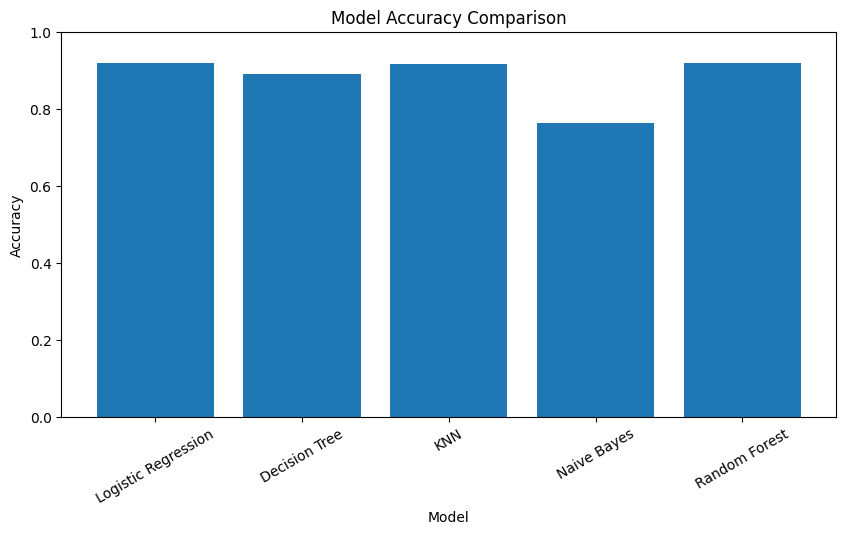

In [38]:
plt.figure(figsize=(10, 5))

plt.bar(results.index, results["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.ylim(0, 1)

plt.show()

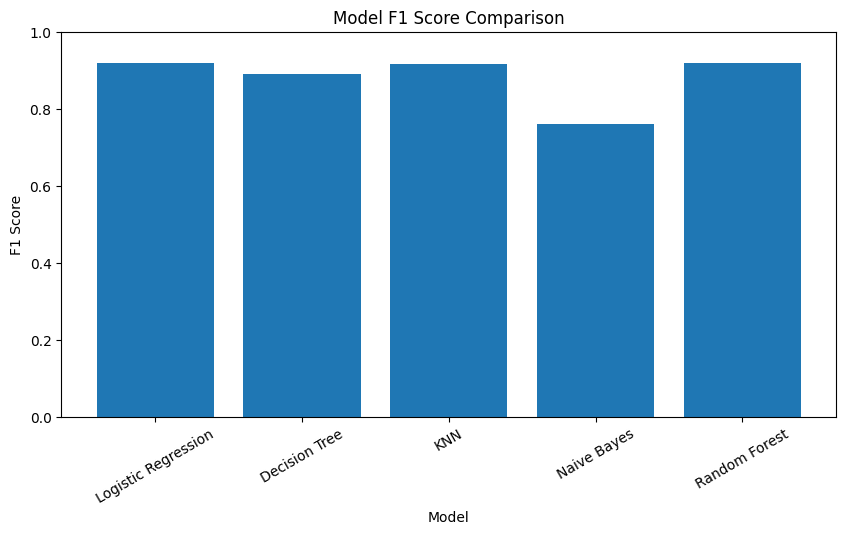

In [39]:
plt.figure(figsize=(10, 5))

plt.bar(results.index, results["F1"])

plt.title("Model F1 Score Comparison")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=30)
plt.ylim(0, 1)

plt.show()

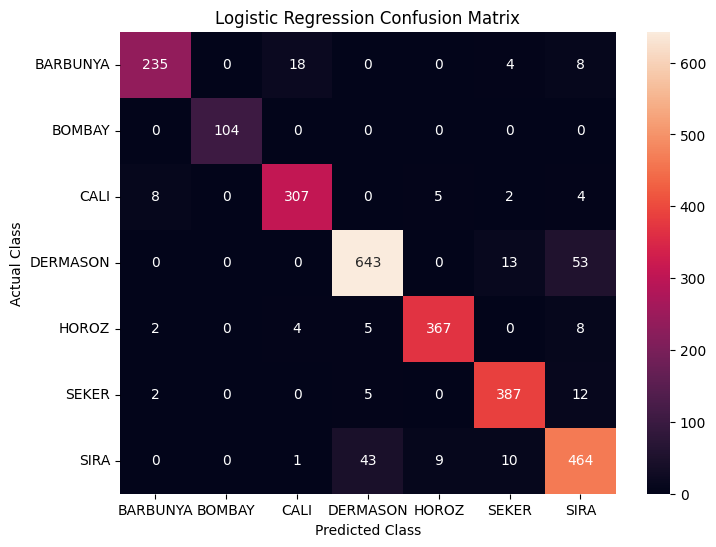

In [40]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr, labels=lr_model.classes_)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=lr_model.classes_,
    yticklabels=lr_model.classes_
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

## 10. Detailed Evaluation of the Best Model

In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

    BARBUNYA       0.95      0.89      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.94      0.94       326
    DERMASON       0.92      0.91      0.92       709
       HOROZ       0.96      0.95      0.96       386
       SEKER       0.93      0.95      0.94       406
        SIRA       0.85      0.88      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



## 12. Save Trained Models and Test Data

In [42]:
import joblib
import os

os.makedirs("model", exist_ok=True)

joblib.dump(lr_model, "model/logistic_regression.pkl")
joblib.dump(dt_model, "model/decision_tree.pkl")
joblib.dump(knn_model, "model/knn.pkl")
joblib.dump(nb_model, "model/naive_bayes.pkl")
joblib.dump(rf_model, "model/random_forest.pkl")

test_data = X_test.copy()
test_data["Class"] = y_test
test_data.to_csv("test_data.csv", index=False)

print("All models saved successfully.")
print("Test data saved successfully.")
print("Test data shape:", test_data.shape)
print("Saved model files:", sorted(os.listdir("model")))
print("Test data exists:", os.path.exists("test_data.csv"))

All models saved successfully.
Test data saved successfully.
Test data shape: (2723, 17)
Saved model files: ['decision_tree.pkl', 'knn.pkl', 'logistic_regression.pkl', 'naive_bayes.pkl', 'random_forest.pkl']
Test data exists: True


## 13. Streamlit Application

The application supports CSV upload, model selection, prediction, all six required metrics, a confusion matrix and a classification report.

In [43]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 72.9 MB/s eta 0:00:00


In [44]:
# Create the final Streamlit application once.
# Feature validation is model-driven so the app uses the exact fitted schema.
app_code = r"""import streamlit as st
import pandas as pd
import joblib

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

st.set_page_config(
    page_title="Dry Bean Classification",
    page_icon="🌱",
    layout="wide"
)

st.title("Dry Bean Classification")
st.write("Compare five machine learning classification models.")

models = {
    "Logistic Regression": joblib.load("model/logistic_regression.pkl"),
    "Decision Tree": joblib.load("model/decision_tree.pkl"),
    "KNN": joblib.load("model/knn.pkl"),
    "Naive Bayes": joblib.load("model/naive_bayes.pkl"),
    "Random Forest": joblib.load("model/random_forest.pkl")
}

model_name = st.selectbox("Select a model", list(models.keys()))
model = models[model_name]

uploaded_file = st.file_uploader(
    "Upload test CSV file",
    type=["csv"]
)

if uploaded_file is not None:
    data = pd.read_csv(uploaded_file)

    st.subheader("Uploaded Data")
    st.write("Rows:", data.shape[0])
    st.write("Columns:", data.shape[1])
    st.dataframe(data.head())

    if "Class" not in data.columns:
        st.error("The uploaded CSV must contain a 'Class' column.")
        st.stop()

    X_uploaded = data.drop(columns=["Class"])
    y_uploaded = data["Class"]

    # Read the feature names from the fitted model rather than hard-coding
    # dataset column names. This keeps the app aligned with the exact
    # training schema saved inside the model pipeline/estimator.
    if not hasattr(model, "feature_names_in_"):
        st.error("The selected saved model does not contain feature-name metadata.")
        st.stop()

    expected_features = list(model.feature_names_in_)
    uploaded_features = list(X_uploaded.columns)

    if uploaded_features != expected_features:
        st.error("Uploaded CSV does not match the feature schema expected by the selected model.")
        st.write("Expected feature columns:", expected_features)
        st.write("Uploaded feature columns:", uploaded_features)
        st.stop()

    predictions = model.predict(X_uploaded)
    probabilities = model.predict_proba(X_uploaded)

    accuracy = accuracy_score(y_uploaded, predictions)
    auc = roc_auc_score(
        y_uploaded,
        probabilities,
        multi_class="ovr",
        labels=model.classes_
    )
    precision = precision_score(y_uploaded, predictions, average="weighted", zero_division=0)
    recall = recall_score(y_uploaded, predictions, average="weighted", zero_division=0)
    f1 = f1_score(y_uploaded, predictions, average="weighted", zero_division=0)
    mcc = matthews_corrcoef(y_uploaded, predictions)

    st.subheader("Predictions")
    st.dataframe(pd.DataFrame({
        "Actual": y_uploaded,
        "Predicted": predictions
    }).head(20))

    st.subheader("Evaluation Metrics")
    metrics = pd.DataFrame({
        "Metric": ["Accuracy", "AUC", "Precision", "Recall", "F1", "MCC"],
        "Score": [accuracy, auc, precision, recall, f1, mcc]
    })
    st.dataframe(metrics)

    st.subheader("Confusion Matrix")
    cm = confusion_matrix(y_uploaded, predictions, labels=model.classes_)
    st.dataframe(pd.DataFrame(cm, index=model.classes_, columns=model.classes_))

    st.subheader("Classification Report")
    report = classification_report(
        y_uploaded,
        predictions,
        labels=model.classes_,
        output_dict=True,
        zero_division=0
    )
    st.dataframe(pd.DataFrame(report).transpose())
"""

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("app.py created successfully.")

app.py created successfully.


## 14. Deployment Requirements

In [45]:
requirements = """streamlit
pandas
numpy
scikit-learn
joblib
matplotlib
seaborn
ucimlrepo
"""

with open("requirements.txt", "w", encoding="utf-8") as f:
    f.write(requirements)

print("requirements.txt created successfully.")

requirements.txt created successfully.


## 15. Project files

```text
dry_bean_classification/
├── app.py
├── requirements.txt
├── README.md
├── test_data.csv
└── model/
    ├── logistic_regression.pkl
    ├── decision_tree.pkl
    ├── knn.pkl
    ├── naive_bayes.pkl
    └── random_forest.pkl
```

In [46]:
import os
import shutil

project_dir = "dry_bean_classification"
os.makedirs(f"{project_dir}/model", exist_ok=True)

for file in ["app.py", "requirements.txt", "test_data.csv"]:
    shutil.copy(file, f"{project_dir}/{file}")

for file in os.listdir("model"):
    shutil.copy(f"model/{file}", f"{project_dir}/model/{file}")

print("Deployment project prepared.")

Deployment project prepared.


## 16. Final Validation

In [47]:
import py_compile

py_compile.compile(f"{project_dir}/app.py", doraise=True)

required_files = [
    f"{project_dir}/app.py",
    f"{project_dir}/requirements.txt",
    f"{project_dir}/test_data.csv",
    f"{project_dir}/model/logistic_regression.pkl",
    f"{project_dir}/model/decision_tree.pkl",
    f"{project_dir}/model/knn.pkl",
    f"{project_dir}/model/naive_bayes.pkl",
    f"{project_dir}/model/random_forest.pkl"
]

print("app.py syntax check: passed")
for file in required_files:
    print("OK" if os.path.exists(file) else "MISSING", "-", file)

app.py syntax check: passed
OK - dry_bean_classification/app.py
OK - dry_bean_classification/requirements.txt
OK - dry_bean_classification/test_data.csv
OK - dry_bean_classification/model/logistic_regression.pkl
OK - dry_bean_classification/model/decision_tree.pkl
OK - dry_bean_classification/model/knn.pkl
OK - dry_bean_classification/model/naive_bayes.pkl
OK - dry_bean_classification/model/random_forest.pkl


## Final Project Preparation

## 17. Streamlit Application Generation — Final Version

The final `app.py` is generated in the previous application-generation cell. There is intentionally no second `app.py` generation block, preventing later cells from silently overwriting the validated application.

In [48]:
import py_compile

py_compile.compile("app.py", doraise=True)

print("Final app.py syntax is correct.")

Final app.py syntax is correct.


In [49]:
import shutil
import os

project_dir = "dry_bean_classification"

shutil.copy("app.py", f"{project_dir}/app.py")

print("Project app.py updated.")

Project app.py updated.


## README Preparation

In [50]:
import os

GITHUB_REPO_URL = "https://github.com/2025ac05114/dry_bean_classification"

# Use the actual results DataFrame rather than hard-coded metric values.
final_results = results.copy()

# Calculate a simple aggregate score because the assignment asks for an
# overall winner but does not define a single winner-selection formula.
metric_columns = ["Accuracy", "AUC", "Precision", "Recall", "F1", "MCC"]
final_results["Overall Score"] = final_results[metric_columns].mean(axis=1)
winner = final_results["Overall Score"].idxmax()

readme = f"""# Dry Bean Classification

## Problem Statement

The aim of this project is to classify dry bean samples into their respective
bean varieties using machine learning classification algorithms.

The dataset contains measurements obtained from images of dry bean samples.
These measurements describe different physical and shape-related properties
of the beans. The task is to use these features to predict the bean class.

Five classification models were implemented and compared:

- Logistic Regression
- Decision Tree
- K-Nearest Neighbors (KNN)
- Naive Bayes
- Random Forest

## Dataset Description

The project uses the UCI Dry Bean dataset.

The dataset contains 13,611 observations and 16 input features. There are
seven different dry bean classes in the target variable.

The 16 features describe properties such as area, perimeter, major and minor
axis length, aspect ratio, eccentricity, convex area, equivalent diameter,
extent, solidity, roundness, compactness and shape factors.

The target variable is `Class`, which represents the type of dry bean.

## GitHub Repository

[GitHub Repository]({GITHUB_REPO_URL})

## Data Preparation

The dataset was inspected to understand its structure, data types, class
distribution, missing values, duplicate records and feature relationships.
Exploratory analysis included feature distributions, outlier visualizations
and a correlation matrix.

The data was divided into training and testing sets using a stratified split,
which keeps the class distribution similar in both sets.

Feature scaling was used for Logistic Regression and KNN. The scaling step was
included inside a pipeline for these models so the same preprocessing is
applied during prediction.

## Machine Learning Models

### Logistic Regression

A linear classification baseline for the multiclass Dry Bean problem.

### Decision Tree

A tree-based classifier that learns classification rules through feature
splits.

### K-Nearest Neighbors

A distance-based classifier. Feature scaling was applied because the model
uses distances between observations.

### Naive Bayes

Gaussian Naive Bayes was used because the input features are numerical.

### Random Forest

An ensemble of decision trees whose combined predictions are used for
classification.

## Model Comparison

The models were evaluated using Accuracy, AUC, Precision, Recall, F1 Score
and Matthews Correlation Coefficient (MCC).

For this multiclass problem, AUC uses the one-vs-rest (`ovr`) strategy.
Precision, Recall and F1 use weighted averaging.

"""

readme += "| Model | Accuracy | AUC | Precision | Recall | F1 | MCC |\n"
readme += "|---|---:|---:|---:|---:|---:|---:|\n"
for model_name, row in final_results.iterrows():
    readme += (
        f"| {model_name} | {row['Accuracy']:.4f} | {row['AUC']:.4f} | "
        f"{row['Precision']:.4f} | {row['Recall']:.4f} | "
        f"{row['F1']:.4f} | {row['MCC']:.4f} |\n"
    )

readme += "\n## Observations\n\n"

for model_name, row in final_results.iterrows():
    accuracy_rank = final_results["Accuracy"].rank(ascending=False, method="min")[model_name]
    f1_rank = final_results["F1"].rank(ascending=False, method="min")[model_name]
    readme += (
        f"### {model_name}\n\n"
        f"{model_name} achieved an accuracy of {row['Accuracy']:.4f}, "
        f"AUC of {row['AUC']:.4f}, F1 score of {row['F1']:.4f} and MCC of "
        f"{row['MCC']:.4f}. It ranked {int(accuracy_rank)} for accuracy and "
        f"{int(f1_rank)} for F1 score among the five implemented models.\n\n"
    )

readme += f"""### Overall Winner

Using the mean of the six required evaluation metrics as the overall score
(the assignment does not prescribe a separate winner-selection rule),
**{winner}** is the overall winner for this test set.

Its aggregate score across Accuracy, AUC, Precision, Recall, F1 and MCC is
**{final_results.loc[winner, 'Overall Score']:.4f}**.

## Project Structure

```text
dry_bean_classification/
├── app.py
├── requirements.txt
├── README.md
├── test_data.csv
└── model/
    ├── logistic_regression.pkl
    ├── decision_tree.pkl
    ├── knn.pkl
    ├── naive_bayes.pkl
    └── random_forest.pkl
```

## How to Run

Install the required Python packages:

```bash
pip install -r requirements.txt
```

Run the Streamlit application:

```bash
streamlit run app.py
```

The application allows the evaluator to upload the supplied test CSV, select
one of the five trained models, view the six evaluation metrics, and inspect
the confusion matrix and classification report.

## Deployment

The Streamlit application is intended to be deployed using Streamlit
Community Cloud from the GitHub repository.

> Before final submission, replace/add the live Streamlit Community Cloud URL
> in the submission PDF after the deployment has been tested successfully.
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme)

print("README.md generated from the final results DataFrame.")
print("GitHub Repository:", GITHUB_REPO_URL)
print("Overall Winner:", winner)
print("Overall Score:", round(final_results.loc[winner, "Overall Score"], 4))

README.md generated from the final results DataFrame.
GitHub Repository: https://github.com/2025ac05114/dry_bean_classification
Overall Winner: Logistic Regression
Overall Score: 0.9305


In [51]:
import os
import shutil

shutil.copy("README.md", f"{project_dir}/README.md")

required_files = [
    "app.py",
    "requirements.txt",
    "README.md",
    "test_data.csv",
    "model/logistic_regression.pkl",
    "model/decision_tree.pkl",
    "model/knn.pkl",
    "model/naive_bayes.pkl",
    "model/random_forest.pkl"
]

print("Final project file check:")
for file in required_files:
    path = os.path.join(project_dir, file)
    print("OK" if os.path.exists(path) else "MISSING", "-", file)

Final project file check:
OK - app.py
OK - requirements.txt
OK - README.md
OK - test_data.csv
OK - model/logistic_regression.pkl
OK - model/decision_tree.pkl
OK - model/knn.pkl
OK - model/naive_bayes.pkl
OK - model/random_forest.pkl


In [53]:
# Project file check
import os

required_files = [
    "app.py",
    "requirements.txt",
    "README.md",
    "test_data.csv",
    "model/logistic_regression.pkl",
    "model/decision_tree.pkl",
    "model/knn.pkl",
    "model/naive_bayes.pkl",
    "model/random_forest.pkl"
]

missing = []
for file in required_files:
    path = os.path.join(project_dir, file)
    if not os.path.exists(path):
        missing.append(file)

print("Required files:", len(required_files))
print("Missing files:", missing if missing else "None")

Required files: 9
Missing files: None
